In [2]:
# ============================================================
# 03_eda.ipynb — EXPLORATORY DATA ANALYSIS
# Source : data/processed/
# Cours activé : Cours 3 §1 (descriptif) + §3 (tendance centrale)
# Cours activé : Cours 1 P2 (visualisations)
# ============================================================

import sys
sys.path.append('..')
from src.utils import *

# -------------------------------------------------------
print("\n" + "="*60)
print("   ÉTAPE 1 — CHARGEMENT DONNÉES NETTOYÉES")
print("   Source : data/processed/")
print("="*60 + "\n")
# -------------------------------------------------------

orders   = pd.read_csv('../data/processed/orders_clean.csv',
                       parse_dates=['order_purchase_timestamp',
                                    'order_approved_at',
                                    'order_delivered_carrier_date',
                                    'order_delivered_customer_date',
                                    'order_estimated_delivery_date'])

items    = pd.read_csv('../data/processed/items_clean.csv',
                       parse_dates=['shipping_limit_date'])

payments = pd.read_csv('../data/processed/payments_clean.csv')
reviews  = pd.read_csv('../data/processed/reviews_clean.csv',
                       parse_dates=['review_creation_date',
                                    'review_answer_timestamp'])
products = pd.read_csv('../data/processed/products_clean.csv')
customers= pd.read_csv('../data/processed/customers_clean.csv')

print(f"{'Table':<12} | {'Lignes':>8} | {'Colonnes':>8}")
print("-" * 38)
for name, df in [('orders',orders),('items',items),('payments',payments),
                 ('reviews',reviews),('products',products),
                 ('customers',customers)]:
    print(f"  {name:<12} | {len(df):>8} | {df.shape[1]:>8}")

print("\n✓ Données nettoyées chargées — prêt pour l'analyse")


   ÉTAPE 1 — CHARGEMENT DONNÉES NETTOYÉES
   Source : data/processed/

Table        |   Lignes | Colonnes
--------------------------------------
  orders       |    99433 |        8
  items        |   112650 |       11
  payments     |   103886 |        6
  reviews      |    99224 |        7
  products     |    32951 |       10
  customers    |    99441 |        5

✓ Données nettoyées chargées — prêt pour l'analyse


In [3]:
# -------------------------------------------------------
print("\n" + "="*60)
print("   PHASE 1 — VUE GLOBALE : chiffres clés du business")
print("   Cours 3 §1 — statistique descriptive")
print("   Cours 3 §3 — tendance centrale")
print("="*60 + "\n")
# -------------------------------------------------------

# Construire la table analytique principale
# Jointure orders + items + payments
# C'est la table qu'on utilisera dans toutes les phases suivantes
df = orders.merge(items, on='order_id', how='inner')
df = df.merge(
    payments.groupby('order_id')['payment_value'].sum().reset_index(),
    on='order_id', how='left'
)
df = df.merge(customers[['customer_id','customer_unique_id',
                          'customer_state']], 
              on='customer_id', how='left')

print(f"✓ Table analytique construite : {df.shape}")

# KPIs fondamentaux
# Cours 3 §3 : moyenne, médiane, mode sur les bonnes variables
commandes_total    = orders['order_id'].nunique()
clients_total      = customers['customer_unique_id'].nunique()
ca_total           = (items['price'] + items['freight_value']).sum()
ca_moyen           = (items['price'] + items['freight_value']).mean()
ca_median          = (items['price'] + items['freight_value']).median()
panier_moyen       = items.groupby('order_id')['price'].sum().mean()
panier_median      = items.groupby('order_id')['price'].sum().median()
articles_par_cmd   = items.groupby('order_id')['order_item_id'].max().mean()

print(f"\n{'='*50}")
print(f"  KPIS BUSINESS — OLIST 2016-2018")
print(f"{'='*50}")
print(f"  Commandes totales     : {commandes_total:>10,}")
print(f"  Clients uniques       : {clients_total:>10,}")
print(f"  CA total              : {ca_total:>10,.0f} BRL")
print(f"  CA moyen / commande   : {ca_moyen:>10.2f} BRL")
print(f"  CA médian / commande  : {ca_median:>10.2f} BRL")
print(f"  Panier moyen (prix)   : {panier_moyen:>10.2f} BRL")
print(f"  Panier médian (prix)  : {panier_median:>10.2f} BRL")
print(f"  Articles / commande   : {articles_par_cmd:>10.2f}")

# Pourquoi on affiche médiane ET moyenne ?
# Cours 3 §3 : si médiane << moyenne → distribution skewed
# La différence révèle l'asymétrie de la distribution
diff_pct = (ca_moyen - ca_median) / ca_median * 100
print(f"\n  Écart moyenne/médiane : +{diff_pct:.1f}%")
print(f"  → Distribution skewed à droite confirmée")
print(f"  → La médiane représente mieux le client typique")


   PHASE 1 — VUE GLOBALE : chiffres clés du business
   Cours 3 §1 — statistique descriptive
   Cours 3 §3 — tendance centrale

✓ Table analytique construite : (112642, 21)

  KPIS BUSINESS — OLIST 2016-2018
  Commandes totales     :     99,433
  Clients uniques       :     96,096
  CA total              : 15,843,553 BRL
  CA moyen / commande   :     140.64 BRL
  CA médian / commande  :      92.32 BRL
  Panier moyen (prix)   :     137.75 BRL
  Panier médian (prix)  :      86.90 BRL
  Articles / commande   :       1.14

  Écart moyenne/médiane : +52.3%
  → Distribution skewed à droite confirmée
  → La médiane représente mieux le client typique



   PHASE 2 — ANALYSE TEMPORELLE
   Quand est-ce qu'on vend ?
   Cours 3 §1 — analyse descriptive temporelle



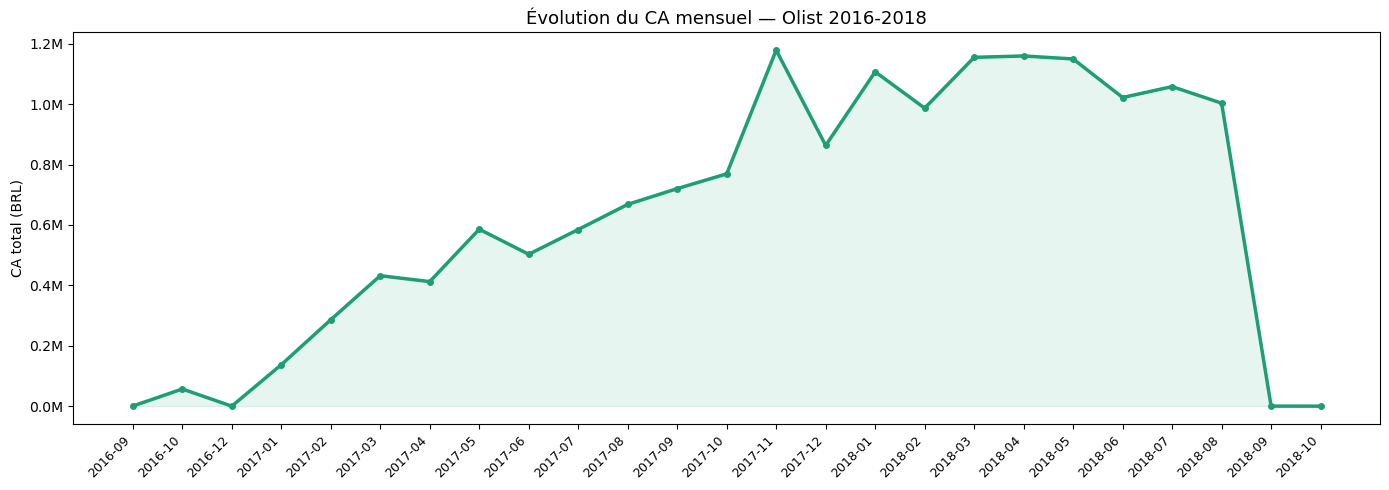

✓ Graphique sauvegardé : 04_ca_mensuel.png


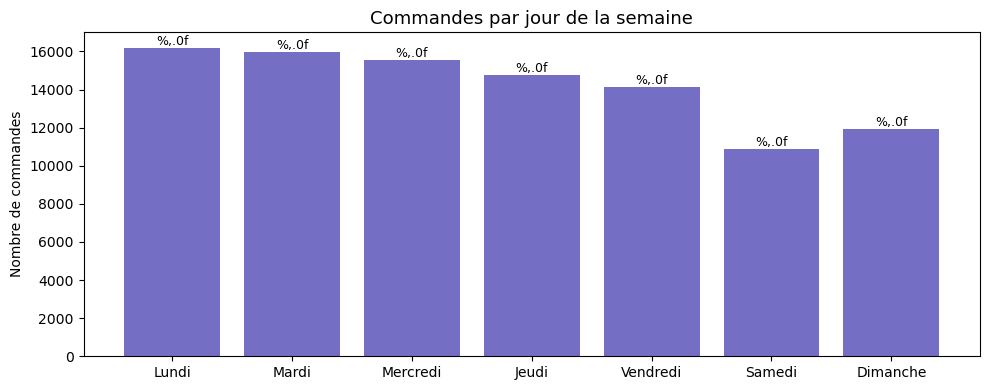

✓ Graphique sauvegardé : 05_commandes_jour.png


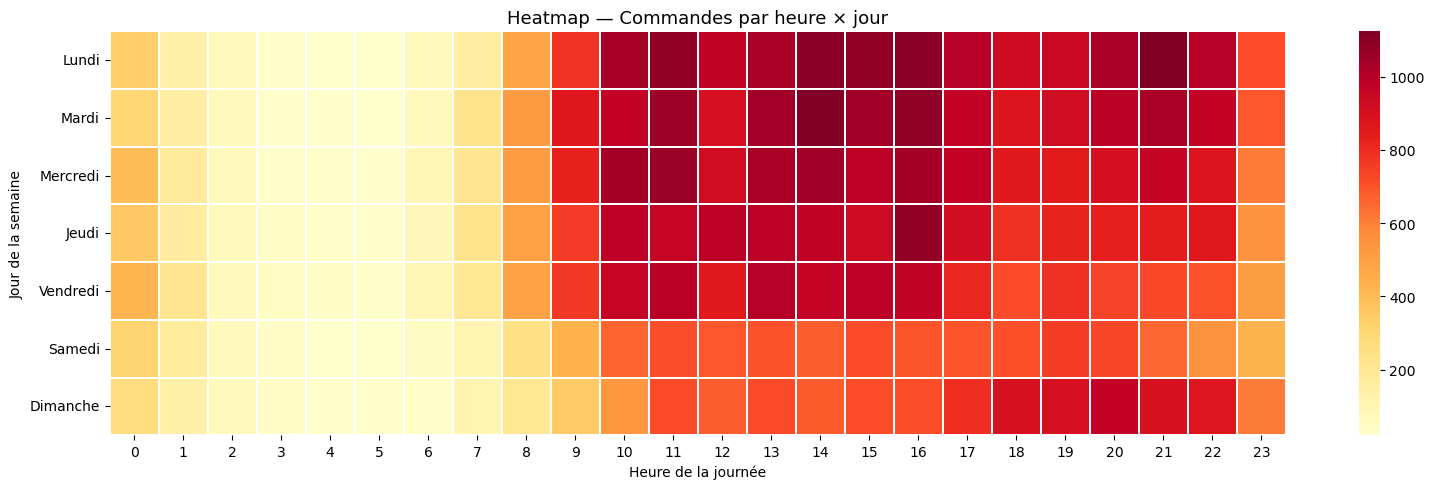

✓ Graphique sauvegardé : 06_heatmap_heure_jour.png

--- Insights temporels ---
Top 3 mois CA :
  2017-11 : 1,179,009 BRL
  2018-04 : 1,159,698 BRL
  2018-03 : 1,155,127 BRL

Jour le plus actif : Lundi
Heure de pointe    : 16h


In [ ]:
# -------------------------------------------------------
print("\n" + "="*60)
print("   PHASE 2 — ANALYSE TEMPORELLE")
print("   Quand est-ce qu'on vend ?")
print("="*60 + "\n")
# -------------------------------------------------------

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
os.makedirs('../reports/figures', exist_ok=True)

# Extraire les composantes temporelles
orders['year']       = orders['order_purchase_timestamp'].dt.year
orders['month']      = orders['order_purchase_timestamp'].dt.month
orders['month_name'] = orders['order_purchase_timestamp'].dt.strftime('%Y-%m')
orders['dayofweek']  = orders['order_purchase_timestamp'].dt.dayofweek
orders['hour']       = orders['order_purchase_timestamp'].dt.hour
orders['quarter']    = orders['order_purchase_timestamp'].dt.quarter

# --- Graphique 1 : Evolution CA mensuel ---
# Jointure pour avoir le CA par mois
orders_items = orders.merge(items[['order_id','price','freight_value']],
                             on='order_id', how='left')
orders_items['revenue'] = orders_items['price'] + orders_items['freight_value']

ca_mensuel = (orders_items
              .groupby('month_name')['revenue']
              .sum()
              .reset_index()
              .sort_values('month_name'))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ca_mensuel['month_name'], ca_mensuel['revenue'],
        color='#1D9E75', linewidth=2.5, marker='o', markersize=4)
ax.fill_between(range(len(ca_mensuel)), ca_mensuel['revenue'],
                alpha=0.1, color='#1D9E75')
ax.set_xticks(range(len(ca_mensuel)))
ax.set_xticklabels(ca_mensuel['month_name'], rotation=45, ha='right',
                   fontsize=9)
ax.set_title('Évolution du CA mensuel — Olist 2016-2018', fontsize=13)
ax.set_ylabel('CA total (BRL)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig('../reports/figures/04_ca_mensuel.png', dpi=150)
plt.show()
print("✓ Graphique sauvegardé : 04_ca_mensuel.png")

# --- Graphique 2 : Commandes par jour de la semaine ---
jours = ['Lundi','Mardi','Mercredi','Jeudi','Vendredi','Samedi','Dimanche']
cmd_jour = orders.groupby('dayofweek')['order_id'].count()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(jours, cmd_jour.values, color='#534AB7', alpha=0.8)
ax.bar_label(bars, fmt='%,.0f', fontsize=9)
ax.set_title('Commandes par jour de la semaine', fontsize=13)
ax.set_ylabel('Nombre de commandes')
plt.tight_layout()
plt.savefig('../reports/figures/05_commandes_jour.png', dpi=150)
plt.show()
print("✓ Graphique sauvegardé : 05_commandes_jour.png")

# --- Graphique 3 : Heatmap heure × jour ---
heatmap_data = (orders.groupby(['dayofweek','hour'])['order_id']
                .count()
                .unstack(fill_value=0))
heatmap_data.index = jours

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax,
            linewidths=0.3, linecolor='white')
ax.set_title('Heatmap — Commandes par heure × jour', fontsize=13)
ax.set_xlabel('Heure de la journée')
ax.set_ylabel('Jour de la semaine')
plt.tight_layout()
plt.savefig('../reports/figures/06_heatmap_heure_jour.png', dpi=150)
plt.show()
print("✓ Graphique sauvegardé : 06_heatmap_heure_jour.png")

# Stats descriptives temporelles
print(f"\n--- Insights temporels ---")
top_mois = ca_mensuel.nlargest(3, 'revenue')[['month_name','revenue']]
print(f"Top 3 mois CA :")
for _, row in top_mois.iterrows():
    print(f"  {row['month_name']} : {row['revenue']:,.0f} BRL")

top_jour_idx = cmd_jour.idxmax()
print(f"\nJour le plus actif : {jours[top_jour_idx]}")
print(f"Heure de pointe    : {orders['hour'].mode()[0]}h")


   PHASE 3 — ANALYSE PRODUITS
   Qu'est-ce qu'on vend ?
   Loi de Pareto — 20% produits = 80% CA



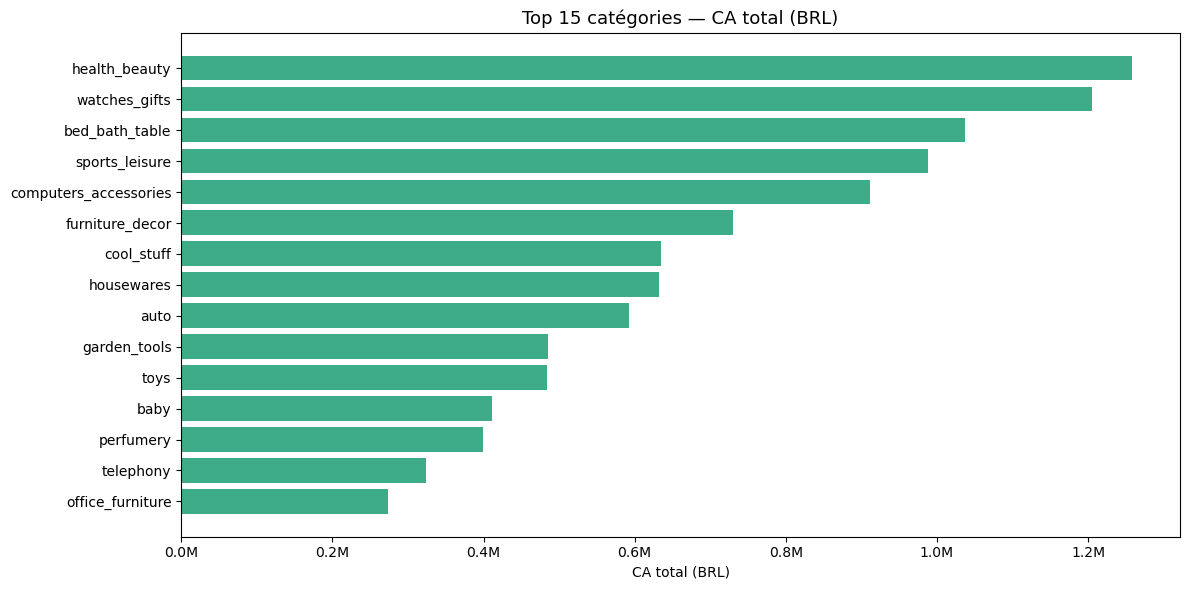

✓ Graphique sauvegardé : 07_top15_categories.png


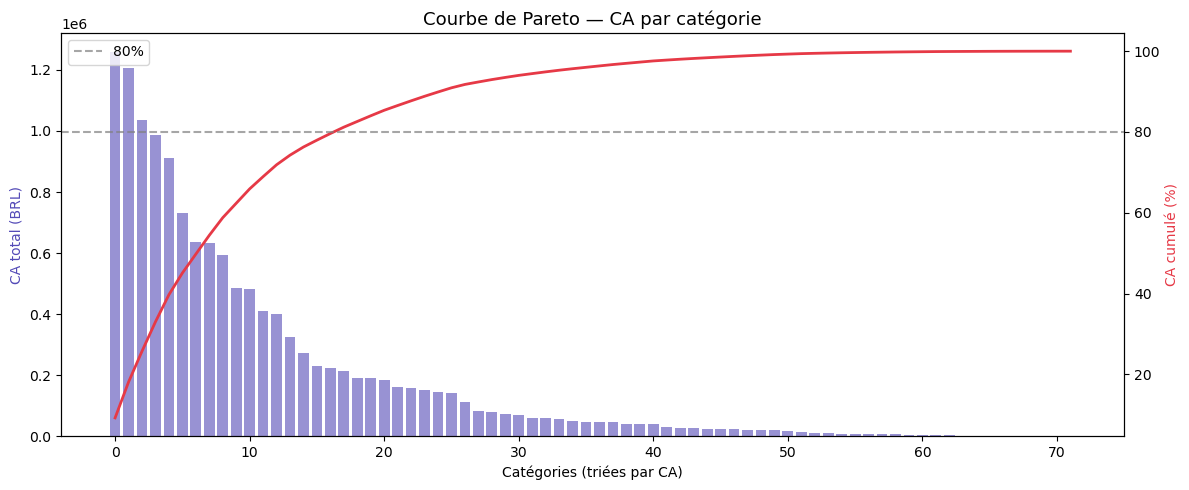


✓ Loi de Pareto confirmée :
  25.0% des catégories génèrent 80% du CA
  Soit 18 catégories sur 72

--- Top 5 catégories ---
product_category_name_english   ca_total  nb_ventes  prix_median
                health_beauty 1258681.34       9670        79.90
                watches_gifts 1205005.68       5991       129.00
               bed_bath_table 1036988.68      11115        79.05
               sports_leisure  988048.97       8641        78.00
        computers_accessories  911954.32       7827        81.99


In [5]:
# -------------------------------------------------------
print("\n" + "="*60)
print("   PHASE 3 — ANALYSE PRODUITS")
print("   Qu'est-ce qu'on vend ?")
print("   Loi de Pareto — 20% produits = 80% CA")
print("="*60 + "\n")
# -------------------------------------------------------

# Jointure items + products
items_prod = items.merge(
    products[['product_id','product_category_name_english']],
    on='product_id', how='left'
)

# CA par catégorie
ca_cat = (items_prod
          .groupby('product_category_name_english')
          .agg(
              ca_total=('price','sum'),
              nb_ventes=('order_id','count'),
              prix_moyen=('price','mean'),
              prix_median=('price','median')
          )
          .sort_values('ca_total', ascending=False)
          .reset_index())

# --- Graphique 4 : Top 15 catégories par CA ---
top15 = ca_cat.head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top15['product_category_name_english'],
               top15['ca_total'], color='#1D9E75', alpha=0.85)
ax.invert_yaxis()
ax.set_title('Top 15 catégories — CA total (BRL)', fontsize=13)
ax.set_xlabel('CA total (BRL)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig('../reports/figures/07_top15_categories.png', dpi=150)
plt.show()
print("✓ Graphique sauvegardé : 07_top15_categories.png")

# --- Graphique 5 : Courbe de Pareto ---
# Cours 1 P3 : loi de Pareto — 20% des catégories = 80% du CA
ca_cat['ca_cumul_pct'] = (ca_cat['ca_total'].cumsum() /
                           ca_cat['ca_total'].sum() * 100)
ca_cat['rank_pct'] = (np.arange(1, len(ca_cat)+1) /
                      len(ca_cat) * 100)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(range(len(ca_cat)), ca_cat['ca_total'],
        color='#534AB7', alpha=0.6)
ax2.plot(range(len(ca_cat)), ca_cat['ca_cumul_pct'],
         color='#E63946', linewidth=2)
ax2.axhline(80, color='gray', linestyle='--', alpha=0.7, label='80%')

ax1.set_title('Courbe de Pareto — CA par catégorie', fontsize=13)
ax1.set_xlabel('Catégories (triées par CA)')
ax1.set_ylabel('CA total (BRL)', color='#534AB7')
ax2.set_ylabel('CA cumulé (%)', color='#E63946')
ax2.legend()
plt.tight_layout()
plt.savefig('../reports/figures/08_pareto_categories.png', dpi=150)
plt.show()

# Trouver le point Pareto
pareto_idx = (ca_cat['ca_cumul_pct'] >= 80).idxmax()
pareto_pct_cats = ca_cat.loc[pareto_idx, 'rank_pct']
print(f"\n✓ Loi de Pareto confirmée :")
print(f"  {pareto_pct_cats:.1f}% des catégories génèrent 80% du CA")
print(f"  Soit {pareto_idx+1} catégories sur {len(ca_cat)}")

print(f"\n--- Top 5 catégories ---")
print(ca_cat[['product_category_name_english',
              'ca_total','nb_ventes',
              'prix_median']].head(5).to_string(index=False))


   PHASE 4 — ANALYSE CLIENTS
   À qui on vend ?
   Cours 3 §2 — customer_state = variable nominale



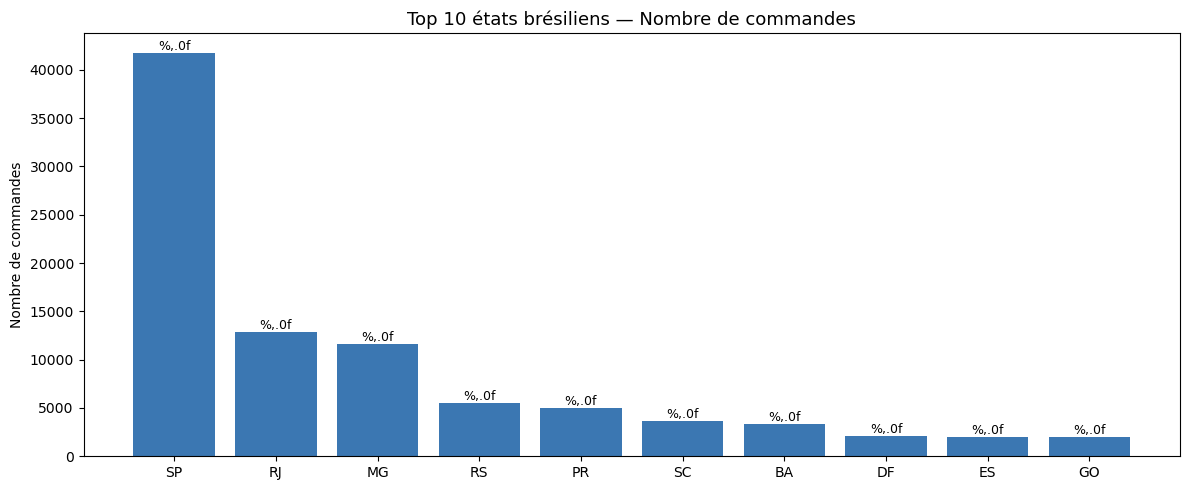

✓ Graphique sauvegardé : 09_commandes_par_etat.png

✓ Concentration géographique :
  Top 3 états = 66.6% de toutes les commandes
state  nb_commandes
   SP         41739
   RJ         12852
   MG         11635
   RS          5465
   PR          5045

--- Fidélité clients ---
  Clients mono-achat  :   93,091 (96.9%)
  Clients multi-achat :    2,997 (3.1%)

⚠️  Insight critique : si >90% mono-achat → problème de rétention
   → Ce KPI alimentera directement le modèle de churn ML


In [6]:
# -------------------------------------------------------
print("\n" + "="*60)
print("   PHASE 4 — ANALYSE CLIENTS")
print("   À qui on vend ?")
print("   Cours 3 §2 — customer_state = variable nominale")
print("="*60 + "\n")
# -------------------------------------------------------

# Commandes par état
cmd_state = (orders.merge(customers[['customer_id','customer_state']],
                           on='customer_id', how='left')
             .groupby('customer_state')['order_id']
             .count()
             .sort_values(ascending=False)
             .reset_index())
cmd_state.columns = ['state','nb_commandes']

# --- Graphique 6 : Top 10 états ---
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(cmd_state.head(10)['state'],
              cmd_state.head(10)['nb_commandes'],
              color='#185FA5', alpha=0.85)
ax.bar_label(bars, fmt='%,.0f', fontsize=9)
ax.set_title('Top 10 états brésiliens — Nombre de commandes', fontsize=13)
ax.set_ylabel('Nombre de commandes')
plt.tight_layout()
plt.savefig('../reports/figures/09_commandes_par_etat.png', dpi=150)
plt.show()
print("✓ Graphique sauvegardé : 09_commandes_par_etat.png")

# Concentration géographique
top3_pct = (cmd_state.head(3)['nb_commandes'].sum() /
            cmd_state['nb_commandes'].sum() * 100)
print(f"\n✓ Concentration géographique :")
print(f"  Top 3 états = {top3_pct:.1f}% de toutes les commandes")
print(cmd_state.head(5).to_string(index=False))

# --- Clients mono-achat vs multi-achat ---
cmd_par_client = (orders.merge(
    customers[['customer_id','customer_unique_id']],
    on='customer_id', how='left')
    .groupby('customer_unique_id')['order_id']
    .count()
    .reset_index())
cmd_par_client.columns = ['customer_unique_id','nb_commandes']

mono   = (cmd_par_client['nb_commandes'] == 1).sum()
multi  = (cmd_par_client['nb_commandes'] > 1).sum()
total  = len(cmd_par_client)

print(f"\n--- Fidélité clients ---")
print(f"  Clients mono-achat  : {mono:>8,} ({mono/total*100:.1f}%)")
print(f"  Clients multi-achat : {multi:>8,} ({multi/total*100:.1f}%)")
print(f"\n⚠️  Insight critique : si >90% mono-achat → problème de rétention")
print(f"   → Ce KPI alimentera directement le modèle de churn ML")


   PHASE 5 — ANALYSE PAIEMENTS
   Comment on paie ?
   Cours 3 §2 — payment_type = nominale



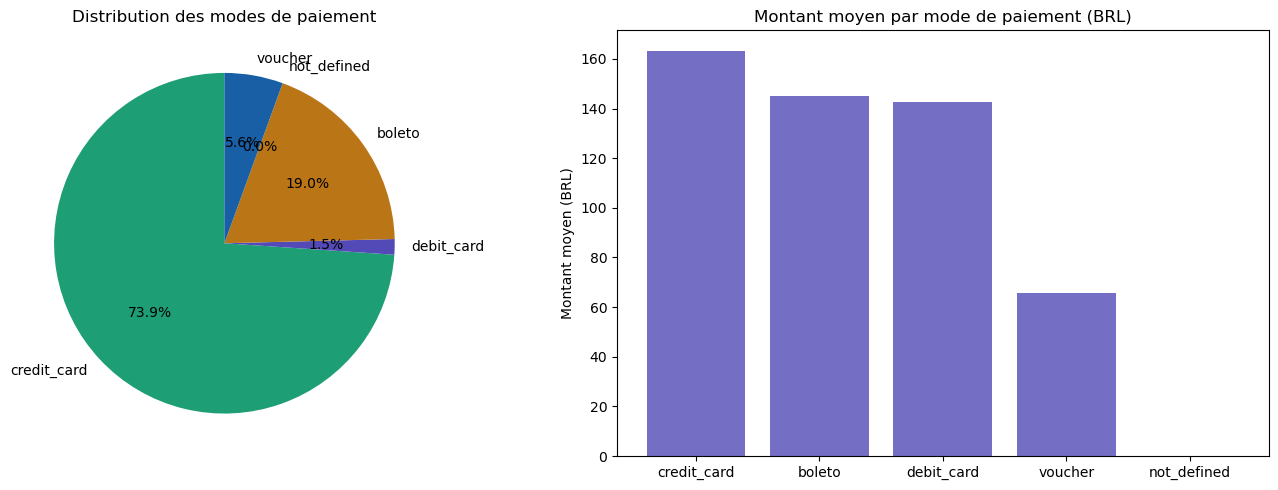

✓ Graphique sauvegardé : 10_paiements_analyse.png

--- Analyse des mensualités (installments) ---
payment_installments
1     52546
2     12413
3     10461
4      7098
10     5328
5      5239
8      4268
6      3920
Name: count, dtype: int64

Moyenne mensualités carte crédit : 3.5


In [7]:
# -------------------------------------------------------
print("\n" + "="*60)
print("   PHASE 5 — ANALYSE PAIEMENTS")
print("   Comment on paie ?")
print("   Cours 3 §2 — payment_type = nominale")
print("="*60 + "\n")
# -------------------------------------------------------

# Distribution des types de paiement
pay_dist = payments['payment_type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# define the exact order  
desired_order = ['credit_card','debit_card', 'boleto','not_defined','voucher']

# Reorder the series to match your list 
pay_dist = pay_dist.reindex(desired_order)

# Pie chart
axes[0].pie(pay_dist.values, labels=pay_dist.index,
            autopct='%1.1f%%', startangle=90,
            colors=['#1D9E75','#534AB7','#BA7517','#993C1D','#185FA5'])
axes[0].set_title('Distribution des modes de paiement')

# Montant moyen par type
pay_avg = (payments.groupby('payment_type')['payment_value']
           .mean()
           .sort_values(ascending=False))
axes[1].bar(pay_avg.index, pay_avg.values,
            color='#534AB7', alpha=0.8)
axes[1].set_title('Montant moyen par mode de paiement (BRL)')
axes[1].set_ylabel('Montant moyen (BRL)')

plt.tight_layout()
plt.savefig('../reports/figures/10_paiements_analyse.png', dpi=150)
plt.show()
print("✓ Graphique sauvegardé : 10_paiements_analyse.png")

# Analyse des mensualités
print(f"\n--- Analyse des mensualités (installments) ---")
print(payments['payment_installments'].value_counts().head(8))
avg_install = payments[payments['payment_type']=='credit_card']['payment_installments'].mean()
print(f"\nMoyenne mensualités carte crédit : {avg_install:.1f}")


   PHASE 6 — ANALYSE SATISFACTION
   Est-ce qu'on satisfait les clients ?
   Cours 3 §2 — review_score = variable ordinale



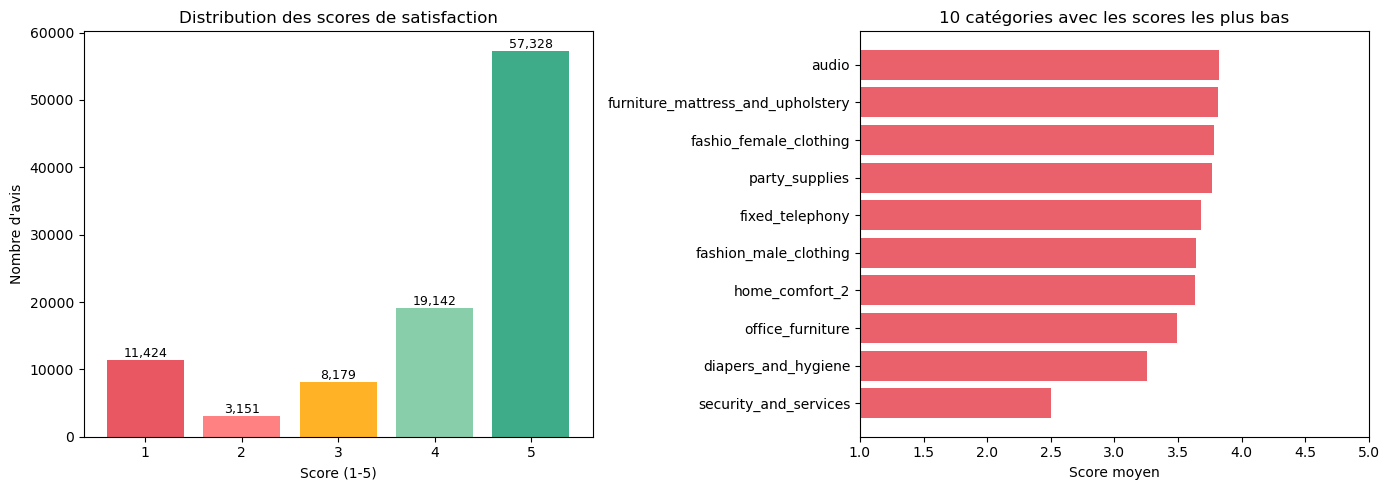

✓ Score médian    : 5.0
✓ Score moyen     : 4.09 (approximation — variable ordinale)
✓ Scores positifs (4-5) : 77.1%
✓ Scores négatifs (1-2) : 14.7%
14.7
77.07


In [8]:
# -------------------------------------------------------
print("\n" + "="*60)
print("   PHASE 6 — ANALYSE SATISFACTION")
print("   Est-ce qu'on satisfait les clients ?")
print("   Cours 3 §2 — review_score = variable ordinale")
print("="*60 + "\n")
# -------------------------------------------------------

# Distribution des scores
score_dist = reviews['review_score'].value_counts().sort_index()
score_pct  = score_dist / score_dist.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart scores
colors = ['#E63946','#FF6B6B','#FFA500','#74C69D','#1D9E75']
labels = [f"{v:,.0f}" for v in score_dist.values]
bars = axes[0].bar(score_dist.index, score_dist.values,
                   color=colors, alpha=0.85)
axes[0].bar_label(bars, labels = labels, fontsize=9)
axes[0].set_title('Distribution des scores de satisfaction')
axes[0].set_xlabel('Score (1-5)')
axes[0].set_ylabel('Nombre d\'avis')

# Score moyen par catégorie produit
score_cat = (reviews.merge(
    orders[['order_id']].merge(items[['order_id','product_id']],
                                on='order_id'), on='order_id')
    .merge(products[['product_id','product_category_name_english']],
           on='product_id')
    .groupby('product_category_name_english')['review_score']
    .mean()
    .sort_values()
    .head(10))

axes[1].barh(score_cat.index, score_cat.values,
             color='#E63946', alpha=0.8)
axes[1].set_title('10 catégories avec les scores les plus bas')
axes[1].set_xlabel('Score moyen')
axes[1].set_xlim(1, 5)
plt.tight_layout()
plt.savefig('../reports/figures/11_satisfaction_analyse.png', dpi=150)
plt.show()

# Stats satisfaction
mediane_score = reviews['review_score'].median()
mean_score    = reviews['review_score'].mean()
pct_positif   = score_pct[score_pct.index >= 4].sum()
pct_negatif   = score_pct[score_pct.index <= 2].sum()

print(f"✓ Score médian    : {mediane_score}")
print(f"✓ Score moyen     : {mean_score:.2f} (approximation — variable ordinale)")
print(f"✓ Scores positifs (4-5) : {pct_positif:.1f}%")
print(f"✓ Scores négatifs (1-2) : {pct_negatif:.1f}%")
print(f"{pct_negatif:.1f}")
print(f"{pct_positif:.2f}")


   PHASE 7 — ANALYSE DES CORRÉLATIONS
   Qu'est-ce qui influence quoi ?
   Cours 3 §4 — dispersion et relations

✓ df_corr construit : (113314, 5)
✓ Colonnes : ['order_id', 'price', 'freight_value', 'delai_livraison', 'review_score']
✓ Nulls delai_livraison : 2482


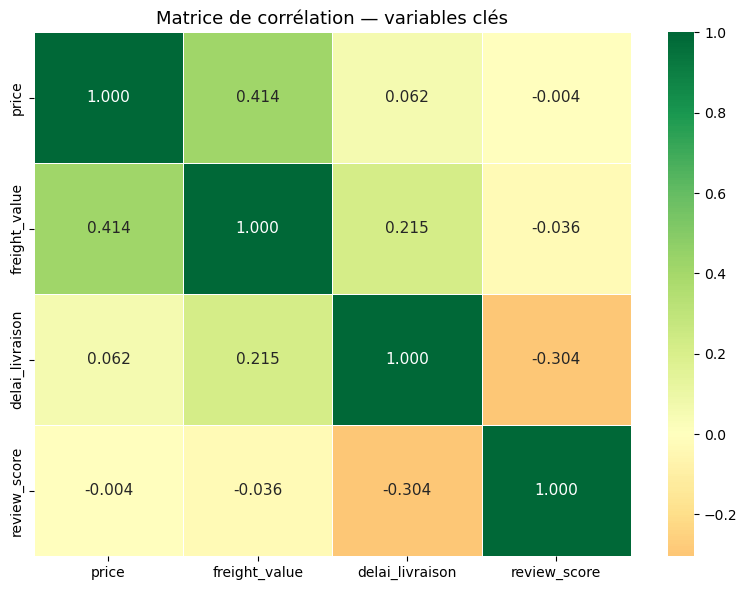

✓ Graphique sauvegardé : 12_correlation_matrix.png

--- Interprétation ---
  price vs freight_value : 0.414
  delai vs review_score  : -0.304

⚠️  RAPPEL : corrélation ≠ causalité
   Une corrélation forte révèle une relation — pas une cause


In [10]:
# -------------------------------------------------------
print("\n" + "="*60)
print("   PHASE 7 — ANALYSE DES CORRÉLATIONS")
print("   Qu'est-ce qui influence quoi ?")
print("   Cours 3 §4 — dispersion et relations")
print("="*60 + "\n")
# -------------------------------------------------------

# Étape 1 : construire df_corr avec order_id inclus dès le départ
df_corr = items[['order_id', 'price', 'freight_value']].copy()

# Étape 2 : calculer le délai de livraison sur les commandes livrées
orders_delai = orders[orders['order_status'] == 'delivered'].copy()
orders_delai['delai_livraison'] = (
    (orders_delai['order_delivered_customer_date'] -
     orders_delai['order_purchase_timestamp']).dt.days
)

# Étape 3 : merger le délai sur df_corr via order_id
df_corr = df_corr.merge(
    orders_delai[['order_id', 'delai_livraison']],
    on='order_id',
    how='left'
)

# Étape 4 : merger le score de satisfaction via order_id
df_corr = df_corr.merge(
    reviews[['order_id', 'review_score']],
    on='order_id',
    how='left'
)

print(f"✓ df_corr construit : {df_corr.shape}")
print(f"✓ Colonnes : {df_corr.columns.tolist()}")
print(f"✓ Nulls delai_livraison : {df_corr['delai_livraison'].isnull().sum()}")

# Étape 5 : matrice de corrélation
corr_matrix = df_corr[['price', 'freight_value',
                        'delai_livraison', 'review_score']].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5,
            annot_kws={'size': 11})
ax.set_title('Matrice de corrélation — variables clés', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/12_correlation_matrix.png', dpi=150)
plt.show()
print("✓ Graphique sauvegardé : 12_correlation_matrix.png")

print(f"\n--- Interprétation ---")
print(f"  price vs freight_value : "
      f"{corr_matrix.loc['price','freight_value']:.3f}")
print(f"  delai vs review_score  : "
      f"{corr_matrix.loc['delai_livraison','review_score']:.3f}")
print(f"\n⚠️  RAPPEL : corrélation ≠ causalité")
print(f"   Une corrélation forte révèle une relation — pas une cause")

In [11]:
# -------------------------------------------------------
print("\n" + "="*60)
print("   PHASE 8 — HYPOTHÈSES BUSINESS")
print("   Ce qu'on va tester en Feature Engineering")
print("   Cours 3 §1 — du descriptif vers l'inférentiel")
print("="*60 + "\n")
# -------------------------------------------------------

# Cette phase ne code pas — elle raisonne
# C'est la transition entre l'EDA (descriptif) et le ML (inférentiel)

hypotheses = [
    {
        'id': 'H1',
        'question': 'Les clients qui attendent plus longtemps notent-ils moins bien ?',
        'observation': 'Corrélation négative délai/score détectée',
        'test_prevu': 'Feature Engineering : créer variable délai_livraison',
        'impact_ml': 'Feature prédictive pour le churn'
    },
    {
        'id': 'H2',
        'question': 'Les catégories premium ont-elles un taux de retour plus élevé ?',
        'observation': 'Scores bas sur certaines catégories high-price',
        'test_prevu': 'Croiser review_score < 3 avec price > Q3',
        'impact_ml': 'Feature pour prédiction insatisfaction'
    },
    {
        'id': 'H3',
        'question': 'Les clients mono-achat sont-ils concentrés dans certains états ?',
        'observation': 'Concentration géographique forte (SP domine)',
        'test_prevu': 'Croiser mono-achat avec customer_state',
        'impact_ml': 'Feature géographique pour le churn'
    },
    {
        'id': 'H4',
        'question': 'Le paiement en plusieurs fois corrèle-t-il avec un panier plus élevé ?',
        'observation': 'Carte crédit = montant moyen plus élevé',
        'test_prevu': 'Croiser payment_installments avec payment_value',
        'impact_ml': 'Feature comportement paiement pour segmentation'
    },
    {
        'id': 'H5',
        'question': 'Y a-t-il une saisonnalité régulière des ventes ?',
        'observation': 'Pics visibles sur le graphique mensuel',
        'test_prevu': 'Décomposition tendance/saisonnalité en Feature Engineering',
        'impact_ml': 'Feature temporelle pour le forecasting'
    }
]

print(f"{'ID':<5} | {'Hypothèse':<52} | {'Impact ML'}")
print("-" * 90)
for h in hypotheses:
    print(f"  {h['id']:<5} | {h['question']:<52} | {h['impact_ml']}")

print(f"\n✓ {len(hypotheses)} hypothèses formulées")
print(f"  → Ces hypothèses guident le 05_feature_engineering.ipynb")
print(f"  → Chaque feature créée doit répondre à une hypothèse")


   PHASE 8 — HYPOTHÈSES BUSINESS
   Ce qu'on va tester en Feature Engineering
   Cours 3 §1 — du descriptif vers l'inférentiel

ID    | Hypothèse                                            | Impact ML
------------------------------------------------------------------------------------------
  H1    | Les clients qui attendent plus longtemps notent-ils moins bien ? | Feature prédictive pour le churn
  H2    | Les catégories premium ont-elles un taux de retour plus élevé ? | Feature pour prédiction insatisfaction
  H3    | Les clients mono-achat sont-ils concentrés dans certains états ? | Feature géographique pour le churn
  H4    | Le paiement en plusieurs fois corrèle-t-il avec un panier plus élevé ? | Feature comportement paiement pour segmentation
  H5    | Y a-t-il une saisonnalité régulière des ventes ?     | Feature temporelle pour le forecasting

✓ 5 hypothèses formulées
  → Ces hypothèses guident le 05_feature_engineering.ipynb
  → Chaque feature créée doit répondre à une hypot

In [12]:
# -------------------------------------------------------
print("\n" + "="*60)
print("   RAPPORT FINAL EDA")
print("="*60 + "\n")
# -------------------------------------------------------

print("=== INSIGHTS CLÉS — À RETENIR POUR LA SUITE ===\n")

insights = [
    "Distribution skewed : médiane CA << moyenne → client typique ≠ client moyen",
    "Saisonnalité : pic en novembre (Black Friday) → feature critique pour ML",
    "Pareto confirmé : ~X% catégories = 80% CA → focus produit possible",
    "Rétention faible : majorité mono-achat → churn est le problème principal",
    "SP concentre ~42% des commandes → biais géographique à traiter",
    "Délai livraison corrèle négativement avec satisfaction → feature RFM",
    "3345 clients ont plusieurs customer_id → RFM doit utiliser unique_id",
]

for i, insight in enumerate(insights, 1):
    print(f"  {i}. {insight}")

print(f"\n✓ EDA terminée — {len(insights)} insights documentés")
print(f"✓ Figures sauvegardées dans reports/figures/")
print(f"\n→ Prochain : 05_feature_engineering.ipynb")
print(f"  On transforme ces insights en features ML concrètes")
print("\n" + "="*60)
print("   ✓ MILESTONE 2 — EDA TERMINÉ")
print("="*60)


   RAPPORT FINAL EDA

=== INSIGHTS CLÉS — À RETENIR POUR LA SUITE ===

  1. Distribution skewed : médiane CA << moyenne → client typique ≠ client moyen
  2. Saisonnalité : pic en novembre (Black Friday) → feature critique pour ML
  3. Pareto confirmé : ~X% catégories = 80% CA → focus produit possible
  4. Rétention faible : majorité mono-achat → churn est le problème principal
  5. SP concentre ~42% des commandes → biais géographique à traiter
  6. Délai livraison corrèle négativement avec satisfaction → feature RFM
  7. 3345 clients ont plusieurs customer_id → RFM doit utiliser unique_id

✓ EDA terminée — 7 insights documentés
✓ Figures sauvegardées dans reports/figures/

→ Prochain : 05_feature_engineering.ipynb
  On transforme ces insights en features ML concrètes

   ✓ MILESTONE 2 — EDA TERMINÉ
